In [25]:
import os
import re
import pickle
import math
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict, defaultdict
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [26]:
import sympy as sp

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [28]:
# Creating the checkpoint directory
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./plots', exist_ok=True)
DATA_DIR = "./data/processed"
os.makedirs(DATA_DIR, exist_ok=True)

In [29]:
class AmplitudeTokenizer:
    def __init__(self, index_pool_size=100, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace

        if special_symbols is None:
            self.special_symbols = [
                '<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>',
                '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
            ]
        else:
            self.special_symbols = special_symbols

        self.index_pool = [f"INDEX_{i}" for i in range(index_pool_size)]
        self.particle_index_pool = [f"PINDEX_{i}" for i in range(index_pool_size)]

        self.pattern_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pattern_num_123 = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')
        self.pattern_momentum = re.compile(r'[ps]_(\d+)')

    @staticmethod
    def remove_whitespace(text):
        return re.sub(r'\s+', '', text)

    @staticmethod
    def split_expression(text):
        return re.split(r' ', text)

    def normalize_indices(self, text):
        if not self.to_replace:
            return text

        text = self.remove_whitespace(text)

        text = re.sub(r'\bs_(\d{2,})\b', lambda m: f'__MAND_{m.group(1)}__', text)

        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r'\bs_(\d+)\b', r'MOMENTUM_\1', text)

        text = re.sub(r'__MAND_(\d+)__', r's_\1', text)

        text = text.replace('\\\\', '\\').replace('\\', r' \ ').replace('%', ' % ')

        index_matches = list(OrderedDict.fromkeys(
            self.pattern_num_123.findall(text)
        ))

        index_iter = iter(self.index_pool)
        index_mapping = {}
        for match in index_matches:
            try:
                index_mapping[match] = next(index_iter)
            except StopIteration:
                raise RuntimeError(f"Index pool exhausted. Increase index_pool_size (currently {self.index_pool_size})")

        for old, new in sorted(index_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        particle_matches = list(OrderedDict.fromkeys(
            m.group('target')
            for m in sorted(self.pattern_particle.finditer(text), key=lambda m: m.start())
        ))

        particle_iter = iter(self.particle_index_pool)
        particle_mapping = {}
        for match in particle_matches:
            try:
                particle_mapping[match] = next(particle_iter)
            except StopIteration:
                raise RuntimeError("Particle index pool exhausted. Increase index_pool_size")

        for old, new in sorted(particle_mapping.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(old, new)

        return text

    def tokenize_amplitude(self, amplitude_text):
        if self.to_replace:
            text = self.normalize_indices(amplitude_text)
        else:
            text = amplitude_text

        text = self.remove_whitespace(text)

        text = text.replace('\\\\', '\\').replace('\\', r' \ ').replace('%', ' % ')
        text = text.replace("(*)", " CONJ ")
        text = text.replace("(theta_W)", "_theta_W")

        for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
            text = text.replace(symbol, f' {symbol} ')

        text = text.replace("_PINDEX", "_ PINDEX").replace("_INDEX", "_ INDEX")
        text = text.replace("reg_prop", " reg_prop ")

        text = re.sub(r' {2,}', ' ', text)

        tokens = [t for t in self.split_expression(text) if t]
        tokens = self.tag_mandelstam(tokens)
        return tokens

    def tokenize_squared(self, squared_text):
      if self.to_replace:
          protected = re.sub(r'\bs_(\d{2,})\b',
                            lambda m: f'__MAND_{m.group(1)}__',
                            squared_text)
          text = self.normalize_indices(protected)
          text = re.sub(r'__MAND_(\d+)__', r's_\1', text)
      else:
          text = squared_text

      text = self.remove_whitespace(text)
      text = text.replace("(theta_W)", "_theta_W")

      for symbol in ['/', '+', '-', '*', ',', '^', '%', '}', '(', ')', '=', '[', ']']:
          text = text.replace(symbol, f' {symbol} ')

      text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)

      text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)

      text = text.replace("reg_prop", " reg_prop ")
      text = re.sub(r' {2,}', ' ', text)

      tokens = [t for t in self.split_expression(text) if t]
      tokens = self.tag_mandelstam(tokens)
      return tokens

    def tag_mandelstam(self, tokens):
        mandelstam_map = {
            's_12': '<S>',       's_21': '<S>',
            's_13': '<T>',       's_31': '<T>',
            's_14': '<U>',       's_41': '<U>',
            's_23': '<U_CROSS>', 's_32': '<U_CROSS>',
            's_24': '<T_CROSS>', 's_42': '<T_CROSS>',
            's_34': '<S_CROSS>', 's_43': '<S_CROSS>',
        }
        return [mandelstam_map.get(tok, tok) for tok in tokens]

    def get_token_types(self, tokens):
        MOMENTUM_TOKENS = {
            '<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'
        }
        SPECIAL_TOKENS = {
            '<PAD>', '<UNK>', '<BOS>', '<EOS>',
            '<SEP>', '<TERM0>', '<TERM1>'
        }
        ALGEBRAIC = {'+', '-', '*', '/', '^', '(', ')', ',', '=', '[', ']', '\\'}

        type_labels = []
        for tok in tokens:
            if tok in MOMENTUM_TOKENS or tok.startswith('MOMENTUM_'):
                type_labels.append(0)
            elif tok.startswith('m_') or tok == 'reg_prop':
                type_labels.append(1)
            elif any(x in tok for x in ['gamma', 'sigma', 'eta', 'eps', 'del',
                                         'tau', 'mu', 'rho', 'gam', 'vho', 'CONJ',
                                         'T_C', 'G_{']):
                type_labels.append(2)
            elif tok.startswith('INDEX_') or tok.startswith('PINDEX_'):
                type_labels.append(3)
            elif tok in SPECIAL_TOKENS:
                type_labels.append(5)
            else:
                type_labels.append(4)
        return type_labels

    def tokenize_with_types(self, amplitude_text):
        tokens = self.tokenize_amplitude(amplitude_text)
        types = self.get_token_types(tokens)
        return tokens, types

In [30]:
# Vocabulary
class Vocabulary:

    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=[5,6]):

        tokens = list(tokens)
        for special in special_symbols:
            if special in tokens:
                tokens.remove(special)

        self.token_list = special_symbols + tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.token_list)}
        self.idx_to_token = {idx: token for token, idx in self.token_to_idx.items()}

        self.pad_idx = pad_idx
        self.unk_idx = unk_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.sep_idx = sep_idx
        self.term_idx = term_idx

        self.pad_tok = special_symbols[pad_idx]
        self.unk_tok = special_symbols[unk_idx]
        self.bos_tok = special_symbols[bos_idx]
        self.eos_tok = special_symbols[eos_idx]
        self.sep_tok = special_symbols[sep_idx]

        self.special_indices = set(self.token_to_idx[sym] for sym in special_symbols)

    def encode(self, tokens):
        return [self.token_to_idx.get(token, self.unk_idx) for token in tokens]

    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(idx, self.unk_tok) for idx in indices]
        else:
            return [
                self.idx_to_token.get(idx, self.unk_tok)
                for idx in indices
                if idx not in self.special_indices or idx == self.sep_idx
            ]

    def __len__(self):
        return len(self.token_list)

    def __getitem__(self, item):
        if isinstance(item, int):
            return self.idx_to_token.get(item, self.unk_tok)
        return self.token_to_idx.get(item, self.unk_idx)

    def tokens(self):
        return self.token_list

Loading the Preprocessed Data with Mandelstam Tokens

In [31]:
# Loading the processed data
DATA_PATH = '/content/data/processed/processed_data2.pkl'

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)


qcd_train = data['qcd']['train']
qcd_val = data['qcd']['val']
qcd_test = data['qcd']['test']

# Extracting vocabularies from QCD data
qcd_src_vocab = data['qcd']['src_vocab']
qcd_tgt_vocab = data['qcd']['tgt_vocab']

print(f"QCD Train: {len(qcd_train)} samples")
print(f"QCD Val: {len(qcd_val)} samples")
print(f"QCD Test: {len(qcd_test)} samples")
print(f"QCD Source vocabulary size: {len(qcd_src_vocab)}")
print(f"QCD Target vocabulary size: {len(qcd_tgt_vocab)}")

QCD Train: 187 samples
QCD Val: 23 samples
QCD Test: 24 samples
QCD Source vocabulary size: 138
QCD Target vocabulary size: 67


In [32]:
# to merge the src and tgt
class UnifiedVocabulary:

    def __init__(self, src_vocab, tgt_vocab):
        special_tokens = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>',
                          '<TERM0>', '<TERM1>', '<S>', '<T>', '<U>',
                          '<S_CROSS>', '<T_CROSS>', '<U_CROSS>']

        all_tokens = []
        seen = set()

        for tok in special_tokens:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        for tok in src_vocab.token_list:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        for tok in tgt_vocab.token_list:
            if tok not in seen:
                all_tokens.append(tok)
                seen.add(tok)

        self.token_list = all_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(all_tokens)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}

        self.pad_idx = self.token_to_idx.get('<PAD>', 0)
        self.bos_idx = self.token_to_idx.get('<BOS>', 2)
        self.eos_idx = self.token_to_idx.get('<EOS>', 3)
        self.unk_idx = self.token_to_idx.get('<UNK>', 1)
        self.sep_idx = self.token_to_idx.get('<SEP>', 4)

        print(f"Unified vocabulary size: {len(self.token_list)}")
        print(f"  Source had: {len(src_vocab)}")
        print(f"  Target had: {len(tgt_vocab)}")
        print(f"  Special tokens: {len(special_tokens)}")

    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, indices, include_special=False):
        tokens = [self.idx_to_token.get(i, '<UNK>') for i in indices]
        if not include_special:
            specials = {'<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>',
                       '<TERM0>', '<TERM1>', '<S>', '<T>', '<U>',
                       '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
            tokens = [t for t in tokens if t not in specials]
        return tokens

    def __len__(self):
        return len(self.token_list)


unified_vocab = UnifiedVocabulary(qed_src_vocab, qed_tgt_vocab)
print(f"\nUsing unified vocabulary with {len(unified_vocab)} tokens")

Unified vocabulary size: 135
  Source had: 125
  Target had: 43
  Special tokens: 13

Using unified vocabulary with 135 tokens


In [33]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                            -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

Physics-Informed Text Encoder

In [34]:
class PhysicsInformedTextEncoder(nn.Module):
    def __init__(self, vocab_size: int, num_types: int = 6, d_model: int = 256,
                 nhead: int = 8, num_layers: int = 4, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model

        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.type_embed = nn.Embedding(num_types, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, token_ids: torch.Tensor, type_ids: torch.Tensor,
                src_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.token_embed(token_ids) + self.type_embed(type_ids)
        x = x * math.sqrt(self.d_model)
        x = self.pos_encoding(x)

        if src_mask is not None:
            key_padding_mask = src_mask
        else:
            key_padding_mask = (token_ids == 0)

        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        return self.layer_norm(x)

In [35]:
class PhysicsInformedModel(nn.Module):
    def __init__(self, vocab_size: int, num_types: int = 6, d_model: int = 256,
                 nhead: int = 8, num_layers: int = 6, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size

        self.text_encoder = PhysicsInformedTextEncoder(
            vocab_size, num_types, d_model, nhead, num_layers, dropout
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)

        self.output_proj = nn.Linear(d_model, vocab_size)

        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout=dropout)

        self.output_proj.weight = self.text_encoder.token_embed.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src_ids: torch.Tensor, src_types: torch.Tensor,
                tgt_ids: torch.Tensor) -> torch.Tensor:
        src_mask = (src_ids == 0)

        memory = self.text_encoder(src_ids, src_types, src_mask)

        tgt_input = tgt_ids
        tgt_emb = self.tgt_embed(tgt_input) * math.sqrt(self.d_model)
        tgt_emb = self.pos_encoding(tgt_emb)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_input.size(1)).to(device)

        output = self.decoder(tgt_emb, memory, tgt_mask=tgt_mask)

        logits = self.output_proj(output)

        return logits

Dataset class

In [36]:
class PhysicsInformedDataset(Dataset):
    def __init__(self, data_list: List[Dict], vocab, max_len: int = 1024, use_physics_masking: bool = True):
        self.data = data_list
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = vocab.pad_idx
        self.bos_idx = vocab.bos_idx
        self.eos_idx = vocab.eos_idx
        self.use_physics_masking = use_physics_masking

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict:
        item = self.data[idx]

        amp_tokens = item['amp_tokens']
        amp_types = item['amp_types']
        sq_tokens = item['sq_tokens']

        src_ids = self.vocab.encode(amp_tokens)
        src_type_ids = amp_types

        src_ids = [self.bos_idx] + src_ids + [self.eos_idx]
        src_type_ids = [5] + src_type_ids + [5]

        # Apply physics-informed masking during training
        if self.use_physics_masking and random.random() < 0.15:
            src_ids, src_type_ids = self._physics_masking(src_ids, src_type_ids)

        tgt_ids = self.vocab.encode(sq_tokens)
        tgt_ids = [self.bos_idx] + tgt_ids + [self.eos_idx]

        src_ids = src_ids[:self.max_len]
        src_type_ids = src_type_ids[:self.max_len]
        tgt_ids = tgt_ids[:self.max_len]

        return {
            'src_ids': torch.tensor(src_ids, dtype=torch.long),
            'src_types': torch.tensor(src_type_ids, dtype=torch.long),
            'tgt_ids': torch.tensor(tgt_ids, dtype=torch.long)
        }

    def _physics_masking(self, src_ids, src_type_ids):
        """Mask entire physical units together for QCD."""
        masked_ids = src_ids.copy()

        # 1. Mask Mandelstam triples together
        mandelstam_tokens = {'<S>', '<T>', '<U>', '<S_CROSS>', '<T_CROSS>', '<U_CROSS>'}
        mandelstam_positions = []

        for i, idx in enumerate(src_ids):
            token = self.vocab.idx_to_token.get(idx, '')
            if token in mandelstam_tokens:
                mandelstam_positions.append(i)

        if len(mandelstam_positions) >= 3:
            for pos in mandelstam_positions[:3]:
                if random.random() < 0.8:
                    masked_ids[pos] = self.vocab.pad_idx

        # 2. Mask coupling constants with exponents (g, g_s, g_s^2, g_s^4)
        coupling_tokens = ['g', 'g_s', 'gs', 'G']
        i = 0
        while i < len(src_ids) - 2:
            token_i = self.vocab.idx_to_token.get(src_ids[i], '')
            token_j = self.vocab.idx_to_token.get(src_ids[i+1], '')
            token_k = self.vocab.idx_to_token.get(src_ids[i+2], '')

            if token_i in coupling_tokens and token_j == '^' and token_k.isdigit():
                if random.random() < 0.5:
                    masked_ids[i] = self.vocab.pad_idx
                    masked_ids[i+1] = self.vocab.pad_idx
                    masked_ids[i+2] = self.vocab.pad_idx
                i += 3
            else:
                i += 1

        return masked_ids, src_type_ids


def collate_fn(batch: List[Dict]) -> Dict:
    src_ids = [item['src_ids'] for item in batch]
    src_types = [item['src_types'] for item in batch]
    tgt_ids = [item['tgt_ids'] for item in batch]

    src_ids_padded = pad_sequence(src_ids, batch_first=True, padding_value=0)
    src_types_padded = pad_sequence(src_types, batch_first=True, padding_value=0)
    tgt_ids_padded = pad_sequence(tgt_ids, batch_first=True, padding_value=0)

    return {
        'src_ids': src_ids_padded,
        'src_types': src_types_padded,
        'tgt_ids': tgt_ids_padded
    }

In [37]:
class PhysicsLossCalculator:
    def __init__(self, vocab):
        self.vocab = vocab
        self.coupling_tokens = ['g', 'g_s', 'gs', 'G']
        self.power_token_idx = vocab.token_to_idx.get('^', None)
        self.s_token_idx = vocab.token_to_idx.get('<S>', None)
        self.s_cross_token_idx = vocab.token_to_idx.get('<S_CROSS>', None)
        self.t_token_idx = vocab.token_to_idx.get('<T>', None)
        self.t_cross_token_idx = vocab.token_to_idx.get('<T_CROSS>', None)
        self.u_token_idx = vocab.token_to_idx.get('<U>', None)
        self.u_cross_token_idx = vocab.token_to_idx.get('<U_CROSS>', None)
        self.reg_prop_idx = vocab.token_to_idx.get('reg_prop', None)
        self.color_tokens = ['T_C', 'G_{', 'f_abc']

    def compute_physics_loss(self, logits):
        pred_indices = logits.argmax(dim=-1)
        physics_loss = 0.0

        for batch in pred_indices:
            coupling_power = 0
            i = 0
            while i < len(batch) - 2:
                token_i = self.vocab.idx_to_token.get(batch[i].item(), '')
                token_j = self.vocab.idx_to_token.get(batch[i+1].item(), '')
                token_k = self.vocab.idx_to_token.get(batch[i+2].item(), '')
                if token_i in self.coupling_tokens and token_j == '^' and token_k.isdigit():
                    coupling_power += int(token_k)
                    i += 3
                else:
                    i += 1
            if coupling_power % 2 != 0:
                physics_loss += 0.3

        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            has_S = '<S>' in tokens
            has_S_cross = '<S_CROSS>' in tokens
            has_T = '<T>' in tokens
            has_T_cross = '<T_CROSS>' in tokens
            has_U = '<U>' in tokens
            has_U_cross = '<U_CROSS>' in tokens

            if has_S != has_S_cross:
                physics_loss += 0.2
            if has_T != has_T_cross:
                physics_loss += 0.2
            if has_U != has_U_cross:
                physics_loss += 0.2

        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            reg_prop_count = tokens.count('reg_prop')
            if reg_prop_count not in [0, 1]:
                physics_loss += 0.2

        for batch in pred_indices:
            tokens = [self.vocab.idx_to_token.get(idx.item(), '') for idx in batch]
            color_count = sum(1 for t in tokens if any(c in t for c in self.color_tokens))
            if color_count % 2 != 0:
                physics_loss += 0.25

        return torch.tensor(physics_loss / len(pred_indices),
                           device=logits.device,
                           dtype=torch.float32,
                           requires_grad=True)

Training and Validation Functions

In [38]:
def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer,
                    criterion: nn.Module, device: torch.device, physics_calc) -> Tuple[float, float]:
    model.train()
    total_ce_loss = 0.0
    total_physics_loss = 0.0
    total_tokens = 0

    for batch in loader:
        src_ids = batch['src_ids'].to(device)
        src_types = batch['src_types'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)

        logits = model(src_ids, src_types, tgt_ids)

        tgt_output = tgt_ids[:, 1:]
        logits = logits[:, :-1, :]

        ce_loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        physics_loss = physics_calc.compute_physics_loss(logits)

        loss = ce_loss + 0.1 * physics_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        num_tokens = (tgt_output != 0).sum().item()
        total_ce_loss += ce_loss.item()
        total_physics_loss += physics_loss.item()
        total_tokens += num_tokens

    return (total_ce_loss / max(total_tokens, 1),
            total_physics_loss / len(loader))


@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader, criterion: nn.Module,
             device: torch.device) -> Tuple[float, float]:
    model.eval()
    total_loss = 0
    total_tokens = 0
    total_correct = 0

    for batch in loader:
        src_ids = batch['src_ids'].to(device)
        src_types = batch['src_types'].to(device)
        tgt_ids = batch['tgt_ids'].to(device)

        logits = model(src_ids, src_types, tgt_ids)

        tgt_output = tgt_ids[:, 1:]
        logits = logits[:, :-1, :]

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        preds = logits.argmax(dim=-1)

        mask = (tgt_output != 0)
        correct = (preds == tgt_output) & mask
        total_correct += correct.sum().item()

        num_tokens = mask.sum().item()
        total_loss += loss.item()
        total_tokens += num_tokens

    return (total_loss / max(total_tokens, 1),
            total_correct / max(total_tokens, 1))

Hyperparameters

In [39]:
# Model architecture
VOCAB_SIZE = len(unified_vocab)
NUM_TYPES = 6
D_MODEL = 512
NHEAD = 8
NUM_LAYERS = 6
DROPOUT = 0.1
MAX_LEN = 1024

# Training
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01
PATIENCE = 10


In [40]:
train_dataset = PhysicsInformedDataset(qcd_train, unified_vocab, max_len=MAX_LEN, use_physics_masking=True)
val_dataset = PhysicsInformedDataset(qcd_val, unified_vocab, max_len=MAX_LEN, use_physics_masking=False)
test_dataset = PhysicsInformedDataset(qcd_test, unified_vocab, max_len=MAX_LEN, use_physics_masking=False)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = PhysicsInformedModel(
    vocab_size=VOCAB_SIZE,
    num_types=NUM_TYPES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT)

# Counting the parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# Create physics loss calculator
physics_calc = PhysicsLossCalculator(unified_vocab)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Loss function (ignore padding index 0)
criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

# Move model to device
model = model.to(device)
print(f"Model moved to: {next(model.parameters()).device}")

# Early stopping
best_val_loss = float('inf')
patience_counter = 0
best_state = None


Total trainable parameters: 44,280,967
Model moved to: cuda:0


Training QCD Model

In [41]:
train_losses = []
val_losses = []
val_accuracies = []
train_physics_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_physics_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device, physics_calc
    )
    scheduler.step()

    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    train_physics_losses.append(train_physics_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, './checkpoints/qcd_best.pt')
        improved = "★"
    else:
        patience_counter += 1
        improved = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
              f"Physics Loss: {train_physics_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {improved}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
    print(f"\n✓ Loaded best model (val_loss: {best_val_loss:.4f})")

Epoch   1/50 | Train Loss: 3.8991 | Physics Loss: 0.0583 | Val Loss: 2.9588 | Val Acc: 0.1446 ★
Epoch   5/50 | Train Loss: 1.3153 | Physics Loss: 0.4960 | Val Loss: 1.2830 | Val Acc: 0.5355 ★
Epoch  10/50 | Train Loss: 0.9968 | Physics Loss: 0.4995 | Val Loss: 0.7995 | Val Acc: 0.7173 ★
Epoch  15/50 | Train Loss: 0.7517 | Physics Loss: 0.5198 | Val Loss: 0.5274 | Val Acc: 0.8054 ★
Epoch  20/50 | Train Loss: 0.6051 | Physics Loss: 0.4790 | Val Loss: 0.3865 | Val Acc: 0.8600 ★
Epoch  25/50 | Train Loss: 0.4928 | Physics Loss: 0.4820 | Val Loss: 0.3072 | Val Acc: 0.8893 ★
Epoch  30/50 | Train Loss: 0.4299 | Physics Loss: 0.4901 | Val Loss: 0.2721 | Val Acc: 0.9039 
Epoch  35/50 | Train Loss: 0.3814 | Physics Loss: 0.4770 | Val Loss: 0.2385 | Val Acc: 0.9105 ★
Epoch  40/50 | Train Loss: 0.3560 | Physics Loss: 0.5031 | Val Loss: 0.2191 | Val Acc: 0.9189 
Epoch  45/50 | Train Loss: 0.3413 | Physics Loss: 0.5128 | Val Loss: 0.2042 | Val Acc: 0.9247 ★
Epoch  50/50 | Train Loss: 0.3338 | Physic

Plotting the QCD Model Training Curves

(0.0, 1.0)

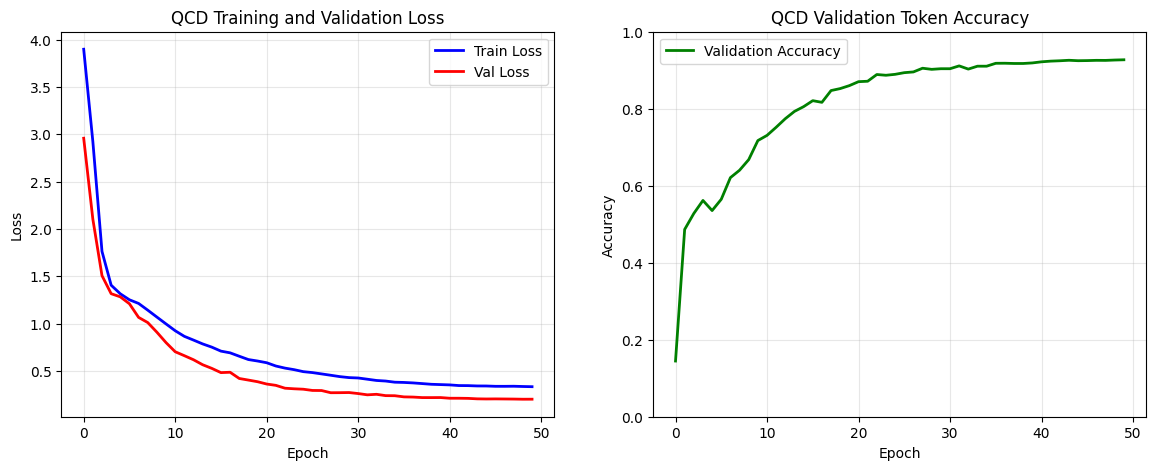

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='blue', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('QCD Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(val_accuracies, label='Validation Accuracy', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('QCD Validation Token Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

In [44]:
test_loss, test_acc = validate(model, test_loader, criterion, device)


print("TEST SET RESULTS (QCD)")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Token Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

TEST SET RESULTS (QCD)
Test Loss: 0.1060
Test Token Accuracy: 0.9644 (96.44%)
